### Imports

In [1]:
from pathlib import Path

import mlflow
import mlflow.xgboost

import numpy as np
import pandas as pd

import xgboost as xgb

import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

### Paths + MLflow

In [ ]:
PROJECT_ROOT = Path.cwd().parent.parent

DATA_PATH = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_PATH / "dvc" / "train_v3.parquet"
TEST_PATH = DATA_PATH / "dvc" / "test_v3.parquet"

BEST_PARAMS_PATH = DATA_PATH / "results" / "best_xgb_params.json"
MLRUNS_PATH = PROJECT_ROOT / "mlruns"

mlflow.set_tracking_uri(
    f"file:{MLRUNS_PATH}"
)

mlflow.set_experiment(
    "simbox_fraud_detection"
)

c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:c:\\Users\\ali.farhat\\Documents\\simbox-project\\mlruns/181740959998191728', creation_time=1781294983928, experiment_id='181740959998191728', last_update_time=1781294983928, lifecycle_stage='active', name='simbox_fraud_detection', tags={}, trace_location=None, workspace='default'>

### Load datasets

In [3]:
train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

print(train_df.shape)
print(test_df.shape)

# Prepare features
drop_cols = [
    "label",
    "msisdn",
    "profile_date"
]

X_train = train_df.drop(
    columns=drop_cols,
    errors="ignore"
)

y_train = train_df["label"]

X_test = test_df.drop(
    columns=drop_cols,
    errors="ignore"
)

y_test = test_df["label"]

print(X_train.shape)
print(X_test.shape)

(343040, 15)
(85760, 15)
(343040, 12)
(85760, 12)


### Hyperparameters

In [4]:
import json

with open(BEST_PARAMS_PATH, "r") as f:
    saved_config = json.load(f)

params = saved_config["params"]

params["scale_pos_weight"] = (
    (y_train == 0).sum()
    /
    (y_train == 1).sum()
)

params["seed"] = 42
params["n_jobs"] = -1

num_boost_round = saved_config["num_boost_round"]

params

{'objective': 'binary:logistic',
 'eval_metric': 'aucpr',
 'eta': 0.04679268676711243,
 'max_depth': 4,
 'min_child_weight': 10,
 'gamma': 0.5,
 'subsample': 0.572249573943548,
 'colsample_bytree': 0.8979068868124158,
 'reg_alpha': 5.899704244372543,
 'reg_lambda': 0.2755180255209402,
 'scale_pos_weight': np.float64(16.39112801013942),
 'seed': 42,
 'n_jobs': -1}

### Train final model

In [5]:
dtrain = xgb.DMatrix(
    X_train,
    label=y_train
)

dtest = xgb.DMatrix(
    X_test,
    label=y_test
)


with mlflow.start_run(
    run_name="final_model_train_v3"
):

    mlflow.log_params(params)

    mlflow.log_param(
        "dataset",
        "train_v3_test_v3"
    )

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=300
    )

    test_pred = model.predict(
        dtest
    )

    pr_auc = average_precision_score(
        y_test,
        test_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        test_pred
    )

    mlflow.log_metric(
        "test_pr_auc",
        pr_auc
    )

    mlflow.log_metric(
        "test_roc_auc",
        roc_auc
    )

    mlflow.xgboost.log_model(
        model,
        "model"
    )


print("PR-AUC:", pr_auc)
print("ROC-AUC:", roc_auc)

2026/07/17 16:31:03 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/07/17 16:31:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instea

PR-AUC: 0.4291988249360476
ROC-AUC: 0.865345494205366


### Find optimal threshold

In [14]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    test_pred
)

f1_scores = (
    2 *
    precision *
    recall
    /
    (precision + recall + 1e-9)
)

best_idx = np.argmax(
    f1_scores
)

best_threshold = (
    thresholds[best_idx]
)

print(
    "Best threshold:",
    best_threshold
)

print(
    "Best F1:",
    f1_scores[best_idx]
)

Best threshold: 0.78940773
Best F1: 0.4043366024944881


### Classification report

In [7]:
test_pred_class = (
    test_pred >= best_threshold
).astype(int)


print(
    classification_report(
        y_test,
        test_pred_class
    )
)

              precision    recall  f1-score   support

           0       0.96      0.97      0.96     80829
           1       0.41      0.40      0.40      4931

    accuracy                           0.93     85760
   macro avg       0.69      0.68      0.68     85760
weighted avg       0.93      0.93      0.93     85760



### Confusion matrix

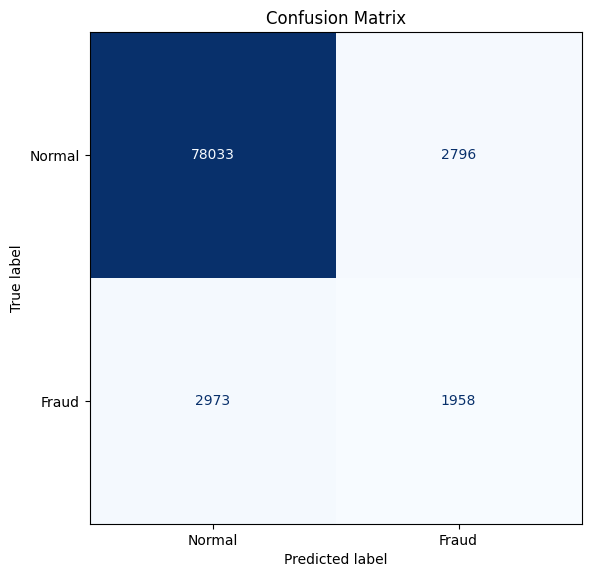

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_pred_class)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

fig, ax = plt.subplots(figsize=(6, 6))

disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Precision Recall curve

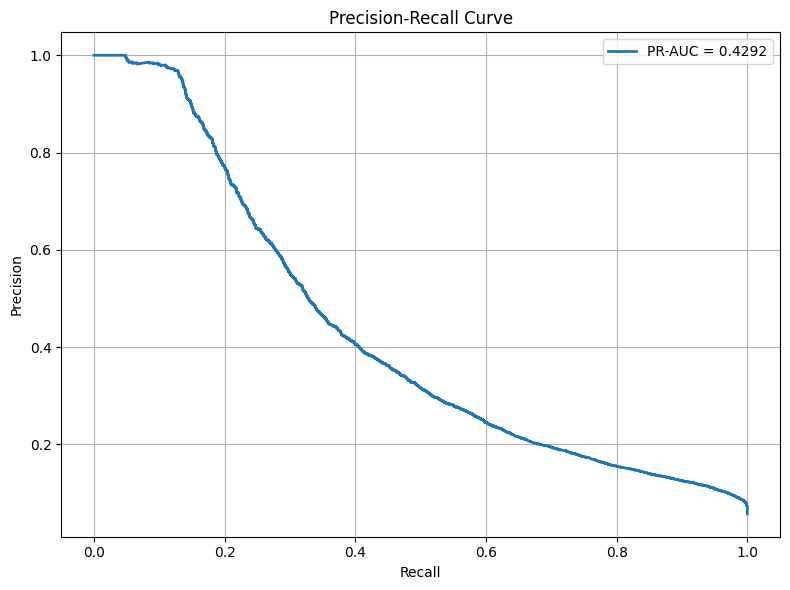

In [9]:
precision, recall, _ = precision_recall_curve(
    y_test,
    test_pred
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"PR-AUC = {pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### ROC-AUC curve

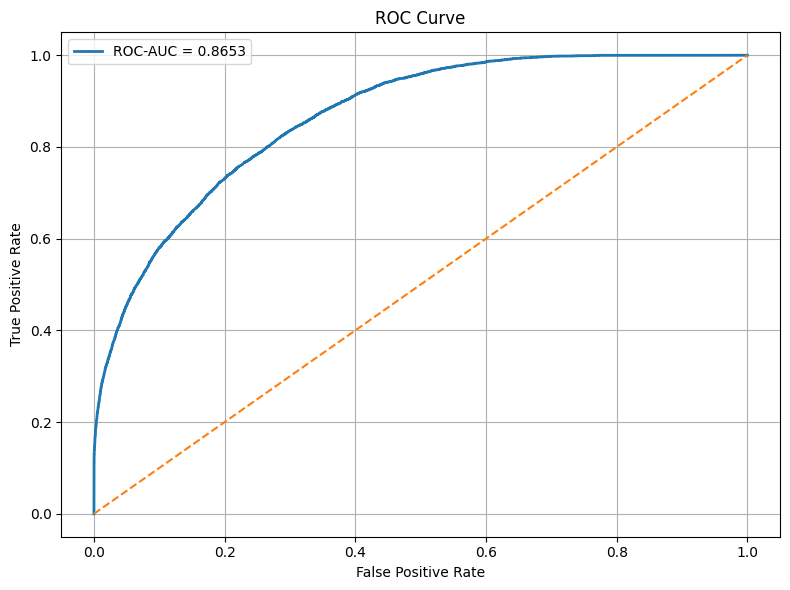

In [10]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    y_test,
    test_pred
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### Probability Distribution

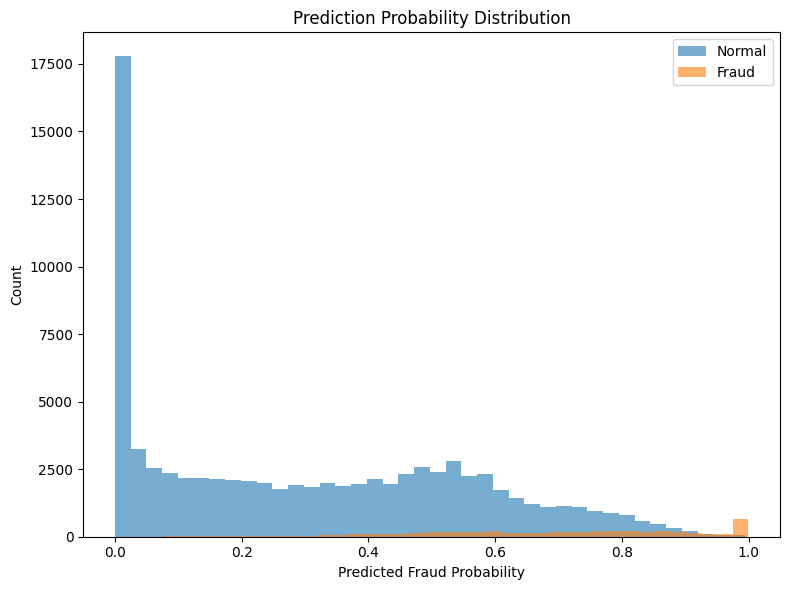

In [11]:
plt.figure(figsize=(8, 6))

plt.hist(
    test_pred[y_test == 0],
    bins=40,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    test_pred[y_test == 1],
    bins=40,
    alpha=0.6,
    label="Fraud"
)

plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Count")
plt.title("Prediction Probability Distribution")
plt.legend()

plt.tight_layout()
plt.show()

### Save predictions

In [12]:
predictions = test_df[
    [
        "msisdn",
        "profile_date",
        "label"
    ]
].copy()

predictions["fraud_probability"] = test_pred

predictions["prediction"] = test_pred_class


PRED_PATH = DATA_PATH / "results" / "predictions_test_v3.parquet"

predictions.to_parquet(
    PRED_PATH,
    index=False
)

print(PRED_PATH)

c:\Users\ali.farhat\Documents\simbox-project\data\results\predictions_test_v3.parquet


### Summary

In [13]:
print("Dataset:")
print("train_v3:", train_df.shape)
print("test_v3:", test_df.shape)

print()

print("Final Metrics")
print("----------------")
print("PR-AUC:", pr_auc)
print("ROC-AUC:", roc_auc)
print("Threshold:", best_threshold)

Dataset:
train_v3: (343040, 15)
test_v3: (85760, 15)

Final Metrics
----------------
PR-AUC: 0.4291988249360476
ROC-AUC: 0.865345494205366
Threshold: 0.78940773
